In [2]:
# Imports gerais do notebook

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

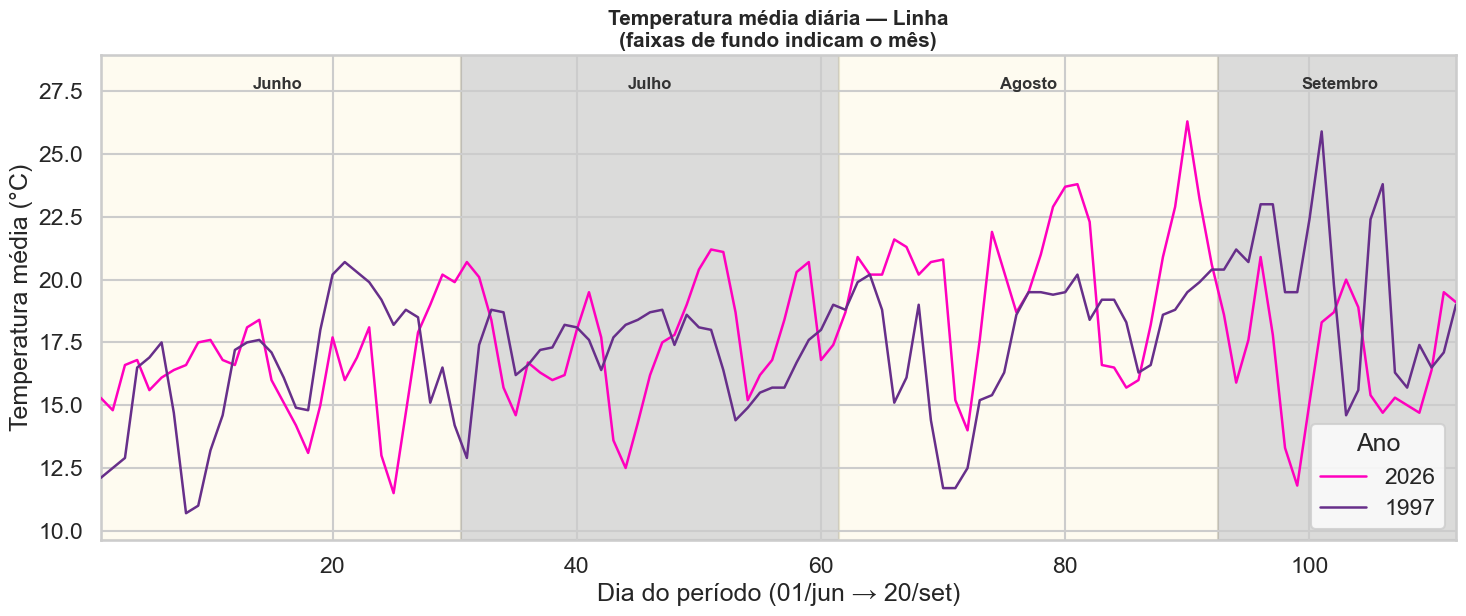

In [5]:
sns.set_theme(style="whitegrid", context="talk")

COR_2025, COR_2026 = "#ff00be", "#672F8A"
a = pd.read_csv("data/gold/ddm_clima_sp_2026-06-01_2026-09-20.csv", parse_dates=["Data"]).sort_values("Data").reset_index(drop=True)
b = pd.read_csv("data/gold/ddm_clima_sp_1997-06-01_1997-09-20.csv", parse_dates=["Data"]).sort_values("Data").reset_index(drop=True)
a["dia_periodo"] = np.arange(1, len(a) + 1)
b["dia_periodo"] = np.arange(1, len(b) + 1)

meses_nome = {6: "Junho", 7: "Julho", 8: "Agosto", 9: "Setembro"}
meses_cores = {6: "#FCF3C4", 7: "#70706D", 8: "#FCF3C4", 9: "#70706D"}
segmentos = a.groupby("mes")["dia_periodo"].agg(["min", "max"]).reset_index()

fig, ax = plt.subplots(figsize=(15, 6.5))
for _, row in segmentos.iterrows():
    mes = int(row["mes"])
    ax.axvspan(row["min"] - 0.5, row["max"] + 0.5, color=meses_cores[mes], alpha=0.25, zorder=0)

ax.plot(a["dia_periodo"], a["Temperatura_media"], color=COR_2025, linewidth=1.8, label="2026", zorder=3)
ax.plot(b["dia_periodo"], b["Temperatura_media"], color=COR_2026, linewidth=1.8, label="1997", zorder=3)

y_top = max(a["Temperatura_media"].max(), b["Temperatura_media"].max()) * 1.1
y_bottom = min(a["Temperatura_media"].min(), b["Temperatura_media"].min()) * 0.9
ax.set_ylim(y_bottom, y_top)
for _, row in segmentos.iterrows():
    mes = int(row["mes"])
    centro = (row["min"] + row["max"]) / 2
    ax.text(centro, y_top * 0.97, meses_nome[mes], ha="center", va="top",
            fontsize=12, fontweight="bold", color="#333333")

ax.set_title("Temperatura média diária — Linha\n(faixas de fundo indicam o mês)", fontsize=15, fontweight="bold")
ax.set_xlabel("Dia do período (01/jun → 20/set)")
ax.set_ylabel("Temperatura média (°C)")
ax.set_xlim(1, max(a["dia_periodo"].max(), b["dia_periodo"].max()))
ax.legend(title="Ano", loc="lower right")
plt.tight_layout()
plt.savefig("p1_a_linha_meses.png", dpi=150)

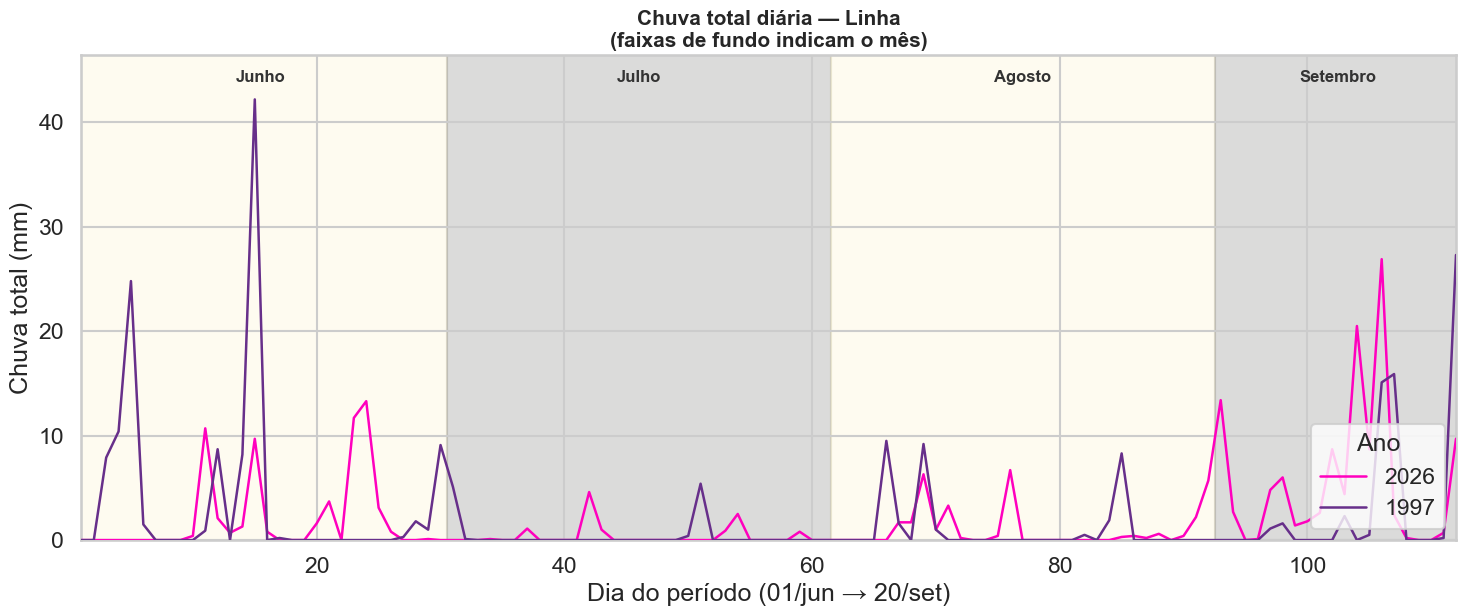

In [3]:
sns.set_theme(style="whitegrid", context="talk")

COR_2025, COR_2026 = "#ff00be", "#672F8A"
a = pd.read_csv("data/gold/ddm_clima_sp_2026-06-01_2026-09-20.csv", parse_dates=["Data"]).sort_values("Data").reset_index(drop=True)
b = pd.read_csv("data/gold/ddm_clima_sp_1997-06-01_1997-09-20.csv", parse_dates=["Data"]).sort_values("Data").reset_index(drop=True)
a["dia_periodo"] = np.arange(1, len(a) + 1)
b["dia_periodo"] = np.arange(1, len(b) + 1)

meses_nome = {6: "Junho", 7: "Julho", 8: "Agosto", 9: "Setembro"}
meses_cores = {6: "#FCF3C4", 7: "#70706D", 8: "#FCF3C4", 9: "#70706D"}
segmentos = a.groupby("mes")["dia_periodo"].agg(["min", "max"]).reset_index()

fig, ax = plt.subplots(figsize=(15, 6.5))
for _, row in segmentos.iterrows():
    mes = int(row["mes"])
    ax.axvspan(row["min"] - 0.5, row["max"] + 0.5, color=meses_cores[mes], alpha=0.25, zorder=0)

ax.plot(a["dia_periodo"], a["Chuva_total"], color=COR_2025, linewidth=1.8, label="2026", zorder=3)
ax.plot(b["dia_periodo"], b["Chuva_total"], color=COR_2026, linewidth=1.8, label="1997", zorder=3)

y_top = max(a["Chuva_total"].max(), b["Chuva_total"].max()) * 1.1
y_bottom = min(a["Chuva_total"].min(), b["Chuva_total"].min()) * 0.9
ax.set_ylim(y_bottom, y_top)
for _, row in segmentos.iterrows():
    mes = int(row["mes"])
    centro = (row["min"] + row["max"]) / 2
    ax.text(centro, y_top * 0.97, meses_nome[mes], ha="center", va="top",
            fontsize=12, fontweight="bold", color="#333333")

ax.set_title("Chuva total diária — Linha\n(faixas de fundo indicam o mês)", fontsize=15, fontweight="bold")
ax.set_xlabel("Dia do período (01/jun → 20/set)")
ax.set_ylabel("Chuva total (mm)")
ax.set_xlim(1, max(a["dia_periodo"].max(), b["dia_periodo"].max()))
ax.legend(title="Ano", loc="lower right")
plt.tight_layout()
plt.savefig("p1_a_linha_meses.png", dpi=150)

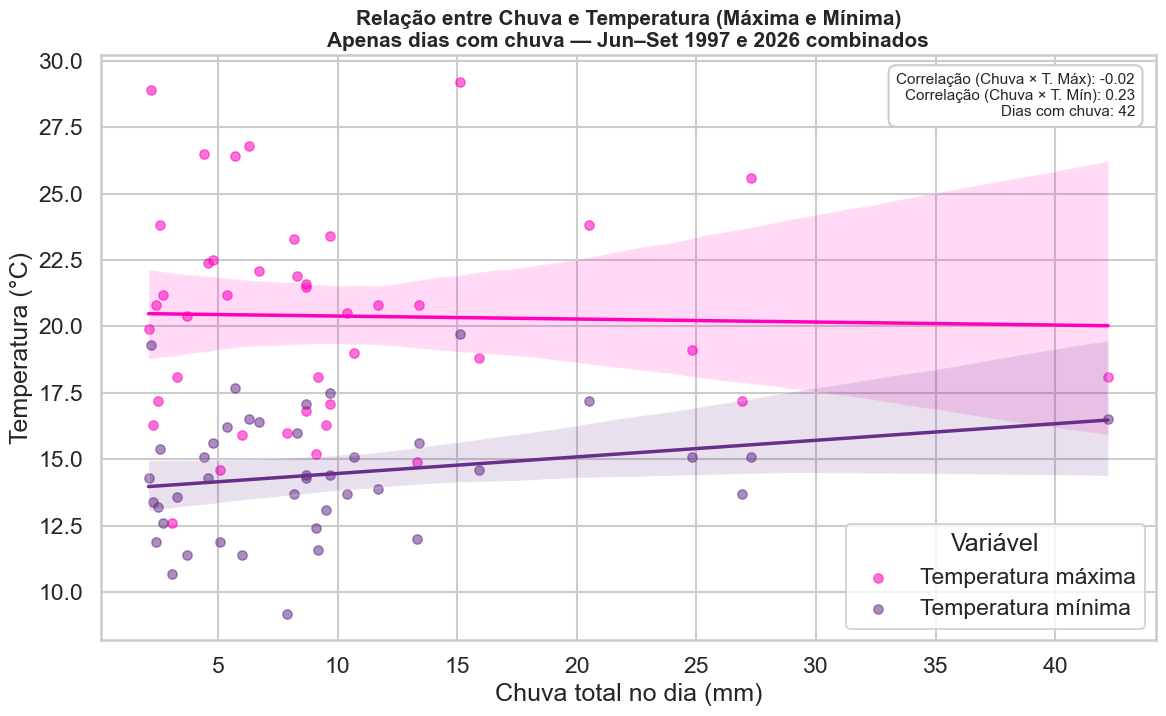

In [12]:
import pandas as pd, matplotlib.pyplot as plt, seaborn as sns

sns.set_theme(style="whitegrid", context="talk")

a = pd.read_csv("data/gold/ddm_clima_sp_2026-06-01_2026-09-20.csv", parse_dates=["Data"])
b = pd.read_csv("data/gold/ddm_clima_sp_1997-06-01_1997-09-20.csv", parse_dates=["Data"])
df = pd.concat([a, b], ignore_index=True)

# --- Filtro: mantém apenas os dias em que choveu (Chuva_total > 5) ---
df = df[df["Chuva_total"] > 2].reset_index(drop=True)

COR_MAX = "#ff00be"   # rosa vibrante — temperatura máxima
COR_MIN = "#672F8A"   # roxo profundo — temperatura mínima

fig, ax = plt.subplots(figsize=(12, 7.5))

sns.regplot(data=df, x="Chuva_total", y="Temperatura_maxima",
            scatter_kws={"alpha": 0.55, "s": 45, "color": COR_MAX},
            line_kws={"color": COR_MAX, "linewidth": 2.5},
            ax=ax, label="Temperatura máxima")

sns.regplot(data=df, x="Chuva_total", y="Temperatura_minima",
            scatter_kws={"alpha": 0.55, "s": 45, "color": COR_MIN},
            line_kws={"color": COR_MIN, "linewidth": 2.5},
            ax=ax, label="Temperatura mínima")

corr_max = df["Chuva_total"].corr(df["Temperatura_maxima"])
corr_min = df["Chuva_total"].corr(df["Temperatura_minima"])
ax.text(0.98, 0.97, f"Correlação (Chuva × T. Máx): {corr_max:.2f}\nCorrelação (Chuva × T. Mín): {corr_min:.2f}\nDias com chuva: {len(df)}",
        transform=ax.transAxes, ha="right", va="top", fontsize=11,
        bbox=dict(boxstyle="round,pad=0.5", facecolor="white", edgecolor="#cccccc"))

ax.set_title("Relação entre Chuva e Temperatura (Máxima e Mínima)\nApenas dias com chuva — Jun–Set 1997 e 2026 combinados",
              fontsize=15, fontweight="bold")
ax.set_xlabel("Chuva total no dia (mm)")
ax.set_ylabel("Temperatura (°C)")
ax.legend(title="Variável", loc="lower right")
plt.tight_layout()
plt.savefig("relacao_chuva_temp_filtrado.png", dpi=150)

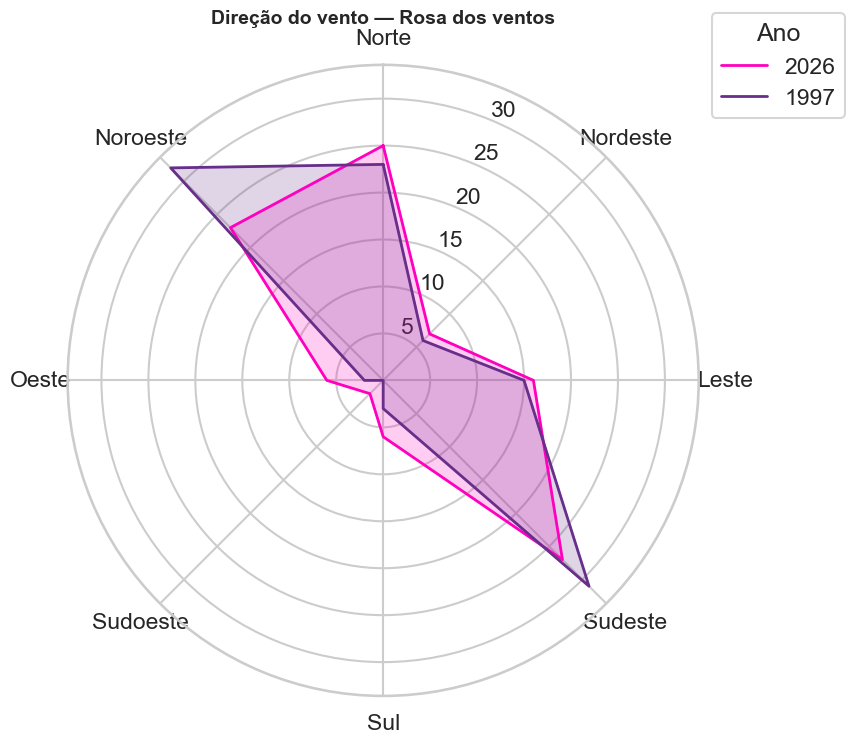

In [6]:
# P6-A: Rosa dos ventos
import pandas as pd, numpy as np, matplotlib.pyplot as plt
COR_2025, COR_2026 = "#ff00be", "#672F8A"
a = pd.read_csv("data/gold/ddm_clima_sp_2026-06-01_2026-09-20.csv", parse_dates=["Data"])
b = pd.read_csv("data/gold/ddm_clima_sp_1997-06-01_1997-09-20.csv", parse_dates=["Data"])
direcoes = ["Norte","Nordeste","Leste","Sudeste","Sul","Sudoeste","Oeste","Noroeste"]
angulos = {d: i*(360/8) for i, d in enumerate(direcoes)}
cont_a = a["Direcao_vento"].value_counts().reindex(direcoes, fill_value=0)
cont_b = b["Direcao_vento"].value_counts().reindex(direcoes, fill_value=0)
theta = np.deg2rad([angulos[d] for d in direcoes]); theta = np.append(theta, theta[0])
va = np.append(cont_a.values, cont_a.values[0]); vb = np.append(cont_b.values, cont_b.values[0])

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw={"projection": "polar"})
ax.set_theta_zero_location("N"); ax.set_theta_direction(-1)
ax.plot(theta, va, color=COR_2025, linewidth=2, label="2026"); ax.fill(theta, va, color=COR_2025, alpha=0.2)
ax.plot(theta, vb, color=COR_2026, linewidth=2, label="1997"); ax.fill(theta, vb, color=COR_2026, alpha=0.2)
ax.set_xticks(np.deg2rad(list(angulos.values()))); ax.set_xticklabels(direcoes)
ax.set_title("Direção do vento — Rosa dos ventos", fontsize=14, fontweight="bold", pad=30)
ax.legend(loc="upper right", bbox_to_anchor=(1.25, 1.1), title="Ano")
plt.tight_layout()
plt.savefig("p6_a_rosa_ventos.png", dpi=150)

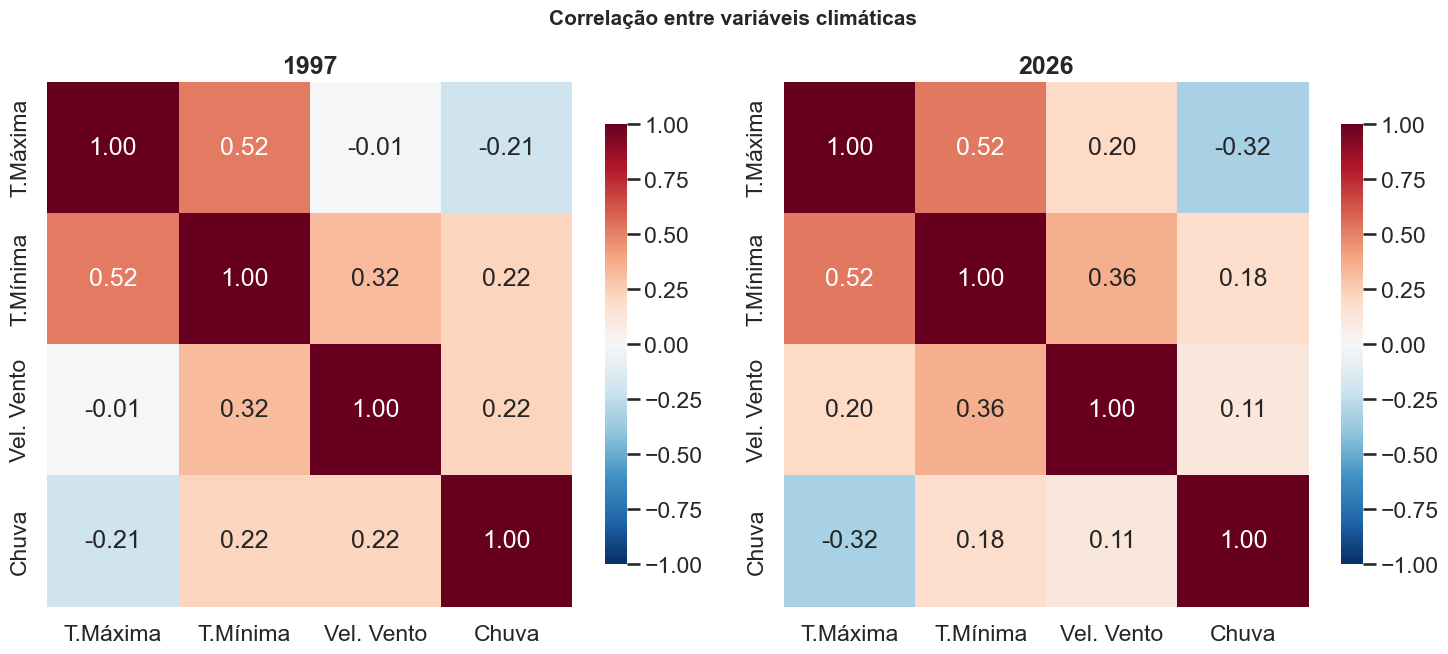

In [8]:
# P8-C: Matriz de correlação
import pandas as pd, matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style="white", context="talk")
a = pd.read_csv("data/gold/ddm_clima_sp_1997-06-01_1997-09-20.csv", parse_dates=["Data"])
b = pd.read_csv("data/gold/ddm_clima_sp_2026-06-01_2026-09-20.csv", parse_dates=["Data"])
variaveis = ["Temperatura_maxima","Temperatura_minima", "Velocidade_vento_max","Chuva_total"]
nomes_curtos = ["T.Máxima","T.Mínima","Vel. Vento","Chuva"]
corr_a = a[variaveis].corr(); corr_a.columns = nomes_curtos; corr_a.index = nomes_curtos
corr_b = b[variaveis].corr(); corr_b.columns = nomes_curtos; corr_b.index = nomes_curtos

fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))
sns.heatmap(corr_a, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, ax=axes[0], square=True, cbar_kws={"shrink": 0.8})
axes[0].set_title("1997", fontweight="bold")
sns.heatmap(corr_b, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, ax=axes[1], square=True, cbar_kws={"shrink": 0.8})
axes[1].set_title("2026", fontweight="bold")
fig.suptitle("Correlação entre variáveis climáticas", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("p8_c_matriz_correlacao.png", dpi=150)

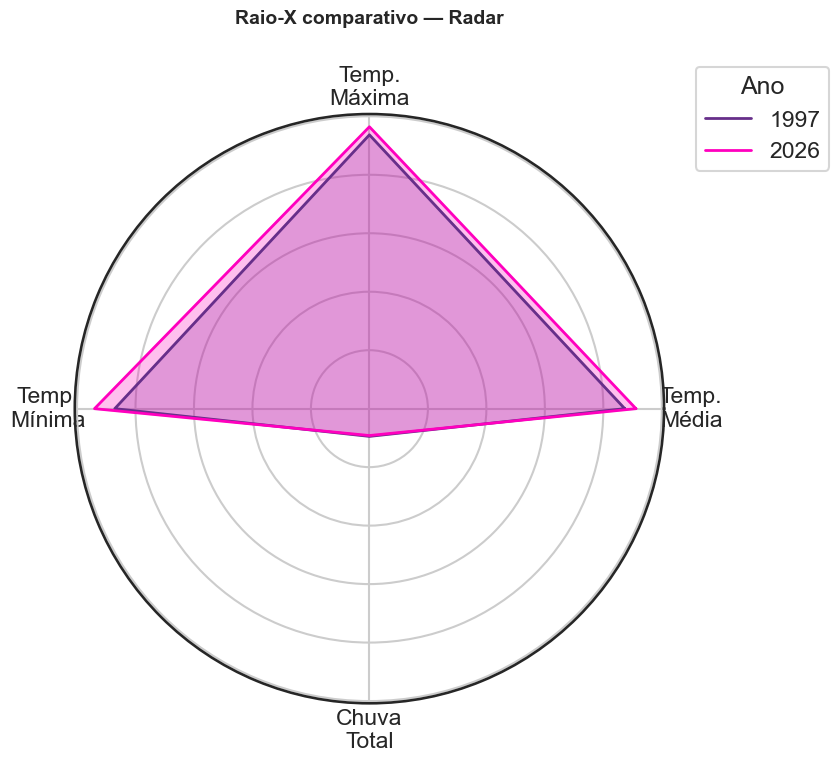

In [10]:
# P10-A: Radar
import pandas as pd, numpy as np, matplotlib.pyplot as plt
COR_2025, COR_2026 = "#672F8A", "#ff00be"
a = pd.read_csv("data/gold/ddm_clima_sp_1997-06-01_1997-09-20.csv", parse_dates=["Data"])
b = pd.read_csv("data/gold/ddm_clima_sp_2026-06-01_2026-09-20.csv", parse_dates=["Data"])
variaveis = ["Temperatura_media","Temperatura_maxima","Temperatura_minima","Chuva_total"]
labels_radar = ["Temp.\nMédia","Temp.\nMáxima","Temp.\nMínima","Chuva\nTotal"]
medias_a = a[variaveis].mean(); medias_b = b[variaveis].mean()
norm_min = pd.concat([a[variaveis], b[variaveis]]).min()
norm_max = pd.concat([a[variaveis], b[variaveis]]).max()
norm_a = ((medias_a - norm_min) / (norm_max - norm_min)).values
norm_b = ((medias_b - norm_min) / (norm_max - norm_min)).values
angles = np.linspace(0, 2*np.pi, len(variaveis), endpoint=False).tolist()
norm_a = np.concatenate((norm_a, [norm_a[0]])); norm_b = np.concatenate((norm_b, [norm_b[0]]))
angles += angles[:1]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw={"projection": "polar"})
ax.plot(angles, norm_a, color=COR_2025, linewidth=2, label="1997"); ax.fill(angles, norm_a, color=COR_2025, alpha=0.25)
ax.plot(angles, norm_b, color=COR_2026, linewidth=2, label="2026"); ax.fill(angles, norm_b, color=COR_2026, alpha=0.25)
ax.set_xticks(angles[:-1]); ax.set_xticklabels(labels_radar); ax.set_yticklabels([])
ax.set_title("Raio-X comparativo — Radar", fontsize=14, fontweight="bold", pad=30)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1), title="Ano")
plt.tight_layout()
plt.savefig("p10_a_radar.png", dpi=150)

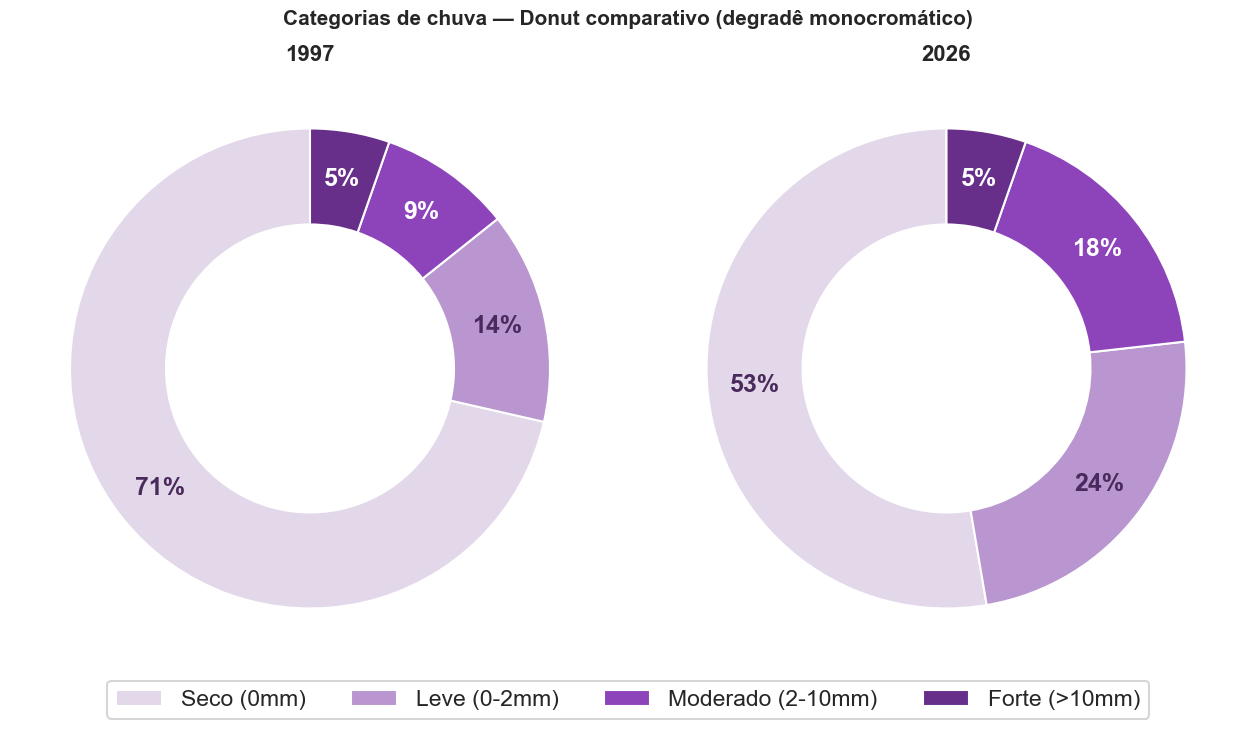

In [12]:
import pandas as pd, matplotlib.pyplot as plt, seaborn as sns
import colorsys

sns.set_theme(style="white", context="talk")

a = pd.read_csv("data/gold/ddm_clima_sp_1997-06-01_1997-09-20.csv", parse_dates=["Data"])
b = pd.read_csv("data/gold/ddm_clima_sp_2026-06-01_2026-09-20.csv", parse_dates=["Data"])

limite = 10
def contar(df):
    return [
        (df["Chuva_total"] == 0).sum(),
        ((df["Chuva_total"] > 0) & (df["Chuva_total"] <= 2)).sum(),
        ((df["Chuva_total"] > 2) & (df["Chuva_total"] <= limite)).sum(),
        (df["Chuva_total"] > limite).sum(),
    ]

categorias = ["Seco (0mm)", "Leve (0-2mm)", "Moderado (2-10mm)", "Forte (>10mm)"]

# --- Degradê monocromático: mesma tonalidade de roxo, variando luminosidade ---
ROXO_BASE = "#672F8A"
r, g, b_ = int(ROXO_BASE[1:3], 16)/255, int(ROXO_BASE[3:5], 16)/255, int(ROXO_BASE[5:7], 16)/255
h, l, s = colorsys.rgb_to_hls(r, g, b_)

niveis_L = [0.88, 0.70, 0.50, l]                # luminosidade decrescente
niveis_S = [s * 0.55, s * 0.75, s * 0.95, s]    # saturação crescente (evita ficar "lavado")

cores = []
for L, S in zip(niveis_L, niveis_S):
    rr, gg, bb = colorsys.hls_to_rgb(h, L, S)
    cores.append((rr, gg, bb))

vals_a, vals_b = contar(a), contar(b)

fig, axes = plt.subplots(1, 2, figsize=(13, 7))
for ax, vals, titulo in zip(axes, [vals_a, vals_b], ["1997", "2026"]):
    wedges, _, autotexts = ax.pie(
        vals,
        colors=cores,
        autopct=lambda p: f"{p:.0f}%" if p > 3 else "",
        startangle=90,
        pctdistance=0.8,
        wedgeprops=dict(width=0.4, edgecolor="white"),
        textprops=dict(fontweight="bold"),
    )
    for wedge, txt in zip(wedges, autotexts):
        rC, gC, bC, _ = wedge.get_facecolor()
        luminancia = 0.299*rC + 0.587*gC + 0.114*bC
        txt.set_color("white" if luminancia < 0.62 else "#4a2a5c")
    ax.set_title(titulo, fontsize=16, fontweight="bold")

fig.suptitle("Categorias de chuva — Donut comparativo (degradê monocromático)", fontsize=15, fontweight="bold")
fig.legend(categorias, loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.05))
plt.tight_layout()
plt.savefig("p7_c_donut_degrade_v3.png", dpi=150, bbox_inches="tight")

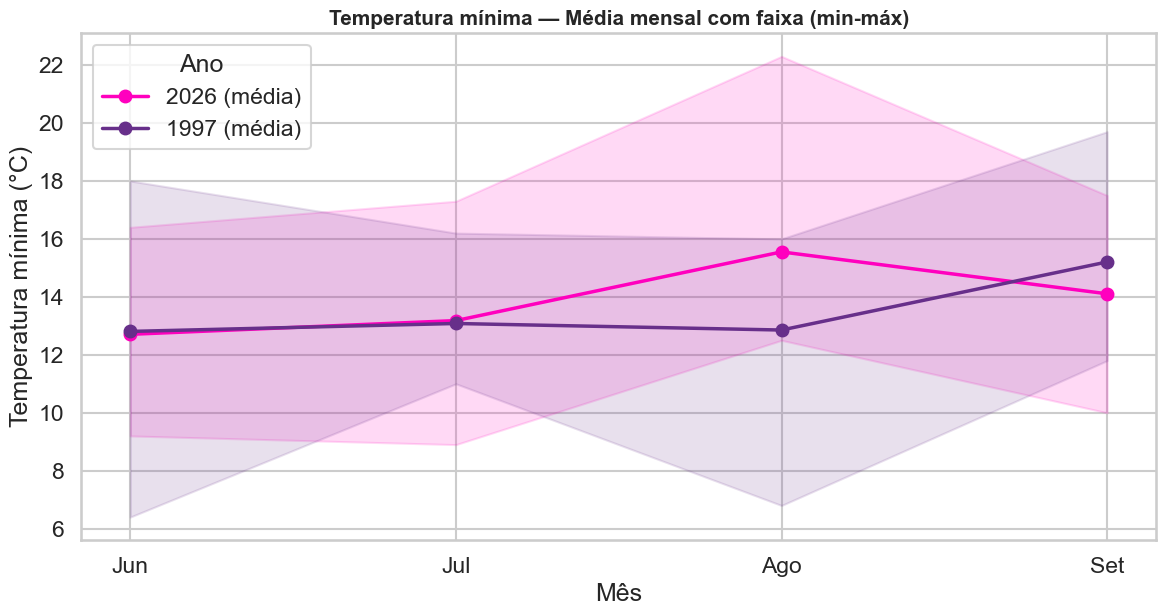

In [14]:
# P9-B: Média mensal com faixa (min-máx)
import pandas as pd, matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style="whitegrid", context="talk")
#COR_2025, COR_2026 = "#A020F0", "#008000"
COR_2025, COR_2026 =  "#ff00be", "#672F8A"
a = pd.read_csv("data/gold/ddm_clima_sp_2026-06-01_2026-09-20.csv", parse_dates=["Data"])
c = pd.read_csv("data/gold/ddm_clima_sp_1997-06-01_1997-09-20.csv", parse_dates=["Data"])
meses_nome = {6:"Jun",7:"Jul",8:"Ago",9:"Set"}; mes_ordem=["Jun","Jul","Ago","Set"]
a["mes_nome"] = a["mes"].map(meses_nome); c["mes_nome"] = c["mes"].map(meses_nome)
resumo_a = a.groupby("mes_nome")["Temperatura_minima"].agg(["mean","min","max"]).reindex(mes_ordem)
resumo_c = c.groupby("mes_nome")["Temperatura_minima"].agg(["mean","min","max"]).reindex(mes_ordem)

fig, ax = plt.subplots(figsize=(12, 6.5))
x = range(len(mes_ordem))
ax.plot(x, resumo_a["mean"], color=COR_2025, marker="o", markersize=9, linewidth=2.5, label="2026 (média)")
ax.fill_between(x, resumo_a["min"], resumo_a["max"], color=COR_2025, alpha=0.15)
ax.plot(x, resumo_c["mean"], color=COR_2026, marker="o", markersize=9, linewidth=2.5, label="1997 (média)")
ax.fill_between(x, resumo_c["min"], resumo_c["max"], color=COR_2026, alpha=0.15)
ax.set_xticks(x); ax.set_xticklabels(mes_ordem)
ax.set_title("Temperatura mínima — Média mensal com faixa (min-máx)", fontsize=15, fontweight="bold")
ax.set_xlabel("Mês"); ax.set_ylabel("Temperatura mínima (°C)")
ax.legend(title="Ano")
plt.tight_layout()
plt.savefig("p9_b_linha_faixa.png", dpi=150)